In [6]:
import torch
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
import torch
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
import numpy as np


In [7]:

# Define facts as [subject, relation, object] triples
# Let's create a small knowledge graph about people and their relationships
facts = torch.tensor([
    [0, 0, 1],  # Person 0 "knows" Person 1
    [1, 0, 2],  # Person 1 "knows" Person 2  
    [2, 1, 3],  # Person 2 "works_with" Person 3
    [3, 1, 4],  # Person 3 "works_with" Person 4
    [4, 2, 0],  # Person 4 "lives_near" Person 0
    [0, 2, 3],  # Person 0 "lives_near" Person 3
    [1, 3, 4],  # Person 1 "manages" Person 4
])

# Extract edges and relation types
edge_index = facts[:, [0, 2]].t()  # [source, target] pairs
edge_type = facts[:, 1]             # relation types

# Create node features (optional)
torch.manual_seed(42)
x = torch.randn(5, 3)  # 5 nodes, 3 features each

# Create the data object
data = Data(x=x, edge_index=edge_index, edge_type=edge_type)

print(f"Original graph: {data.num_nodes} nodes, {data.num_edges} edges")
print(f"Relation types: {torch.unique(edge_type).tolist()}")

# Define relation labels for visualization
relation_labels = {0: "knows", 1: "works_with", 2: "lives_near", 3: "manages"}
node_labels = {0: "Alice", 1: "Bob", 2: "Charlie", 3: "Diana", 4: "Eve"}

Original graph: 5 nodes, 7 edges
Relation types: [0, 1, 2, 3]


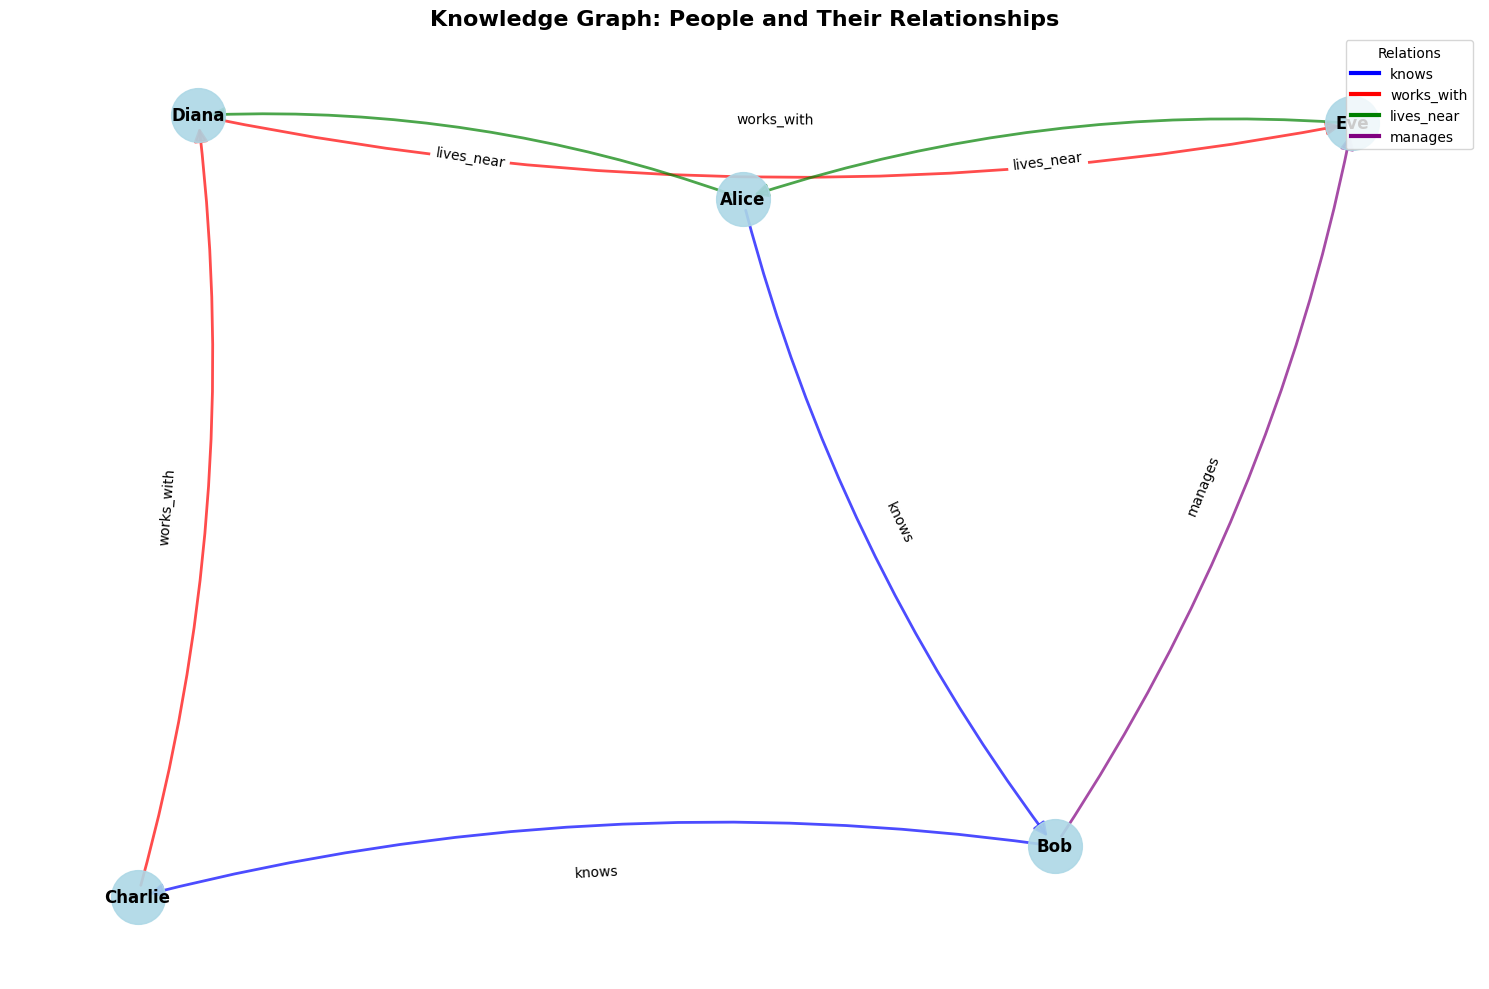

In [8]:
# Convert to NetworkX for visualization
G = nx.DiGraph()  # Directed graph to show relation directions

# Add nodes
for i in range(data.num_nodes):
    G.add_node(i, label=node_labels[i])

# Add edges with relation types
for i, (src, dst) in enumerate(edge_index.t().numpy()):
    rel_type = edge_type[i].item()
    G.add_edge(src, dst, relation=relation_labels[rel_type], rel_id=rel_type)

# Create visualization
plt.figure(figsize=(15, 10))

# Define colors for different relation types
relation_colors = {0: 'blue', 1: 'red', 2: 'green', 3: 'purple'}
edge_colors = [relation_colors[G[u][v]['rel_id']] for u, v in G.edges()]

# Create layout
pos = nx.spring_layout(G, seed=42, k=2, iterations=50)

# Draw nodes
nx.draw_networkx_nodes(G, pos, 
                      node_color='lightblue', 
                      node_size=1500, 
                      alpha=0.9)

# Draw node labels (person names)
node_label_dict = {i: node_labels[i] for i in range(data.num_nodes)}
nx.draw_networkx_labels(G, pos, node_label_dict, font_size=12, font_weight='bold')

# Draw edges with different colors for different relations
for rel_id, color in relation_colors.items():
    edge_list = [(u, v) for u, v in G.edges() if G[u][v]['rel_id'] == rel_id]
    if edge_list:
        nx.draw_networkx_edges(G, pos, edgelist=edge_list, 
                             edge_color=color, arrows=True, 
                             arrowsize=20, width=2, alpha=0.7,
                             connectionstyle="arc3,rad=0.1")

# Add edge labels
edge_labels = {(u, v): G[u][v]['relation'] for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=10)

# Create legend
legend_elements = [plt.Line2D([0], [0], color=color, lw=3, label=relation_labels[rel_id]) 
                  for rel_id, color in relation_colors.items()]
plt.legend(handles=legend_elements, loc='upper right', title='Relations')

plt.title("Knowledge Graph: People and Their Relationships", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
data

Data(x=[5, 3], edge_index=[2, 7], edge_type=[7])

In [21]:
from torch_geometric.transforms import RandomLinkSplit

# Apply link splitting to the knowledge graph
link_split = RandomLinkSplit(num_val=0.0, num_test=0.0, disjoint_train_ratio=0.5, add_negative_train_samples=False)
train_data, val_data, test_data = link_split(data)

print(f"\nAfter Link Splitting:")
print(f"Train data: {train_data}")
print(f"Valid data: {val_data}")
print(f"Test data: {test_data}")


After Link Splitting:
Train data: Data(x=[5, 3], edge_index=[2, 4], edge_type=[4], edge_label=[3], edge_label_index=[2, 3])
Valid data: Data(x=[5, 3], edge_index=[2, 7], edge_type=[7], edge_label=[0], edge_label_index=[2, 0])
Test data: Data(x=[5, 3], edge_index=[2, 7], edge_type=[7], edge_label=[0], edge_label_index=[2, 0])


In [22]:
print(f"\nTraining facts (edges kept):")
for i, (src, dst) in enumerate(train_data.edge_index.t().numpy()):
    print(f"- {node_labels[src]} -> {node_labels[dst]}")


Training facts (edges kept):
- Bob -> Charlie
- Alice -> Diana
- Alice -> Bob
- Diana -> Eve


In [17]:

print(f"\nValidation positive facts (edges to predict):")
for i, (src, dst) in enumerate(val_data.edge_label_index.t().numpy()):
    print(f"- {node_labels[src]} -> {node_labels[dst]}")


Validation positive facts (edges to predict):
- Alice -> Bob
- Charlie -> Alice


In [ ]:
from __future__ import annotations

import torch
from torch import Tensor
from torch_geometric.utils import coalesce


def remove_overlapping_edges(
    edge_index: Tensor,
    edge_label_index: Tensor,
    edge_label: Tensor | None = None,
    device: str | torch.device | None = None
) -> tuple[Tensor, Tensor | None]:
    """Remove edges from edge_label_index that exist in edge_index using PyG utilities.
    
    Args:
        edge_index: Graph edges for message passing with shape [2, num_edges]
        edge_label_index: Target edges for prediction with shape [2, num_label_edges]
        edge_label: Optional labels for target edges with shape [num_label_edges]
        
    Returns:
        Tuple containing:
        - filtered_edges: Filtered edge_label_index with overlapping edges removed
        - filtered_labels: Corresponding filtered edge labels, or None if edge_label was None
        
    Example:
        >>> edge_index = torch.tensor([[0, 1, 2], [1, 2, 3]])
        >>> edge_label_index = torch.tensor([[0, 2, 3], [1, 3, 4]])
        >>> edge_label = torch.tensor([0, 1, 2])
        >>> filtered_edges, filtered_labels = remove_overlapping_edges(
        ...     edge_index, edge_label_index, edge_label
        ... )
        >>> print(filtered_edges)  # Should exclude [0, 1] overlap
        tensor([[2, 3],
                [3, 4]])
        >>> print(filtered_labels)
        tensor([1, 2])
    """

    if device is None:
        device = edges_to

    
    # Combine all edges to find overlaps
    all_edges: Tensor = torch.cat([edge_index, edge_label_index], dim=1)
    
    # Create edge attributes to track which edges are from which set
    edge_index_mask: Tensor = torch.zeros(edge_index.size(1), dtype=torch.bool)
    label_mask: Tensor = torch.ones(edge_label_index.size(1), dtype=torch.bool)
    all_masks: Tensor = torch.cat([edge_index_mask, label_mask])
    
    # Use coalesce to find unique edges and their indices
    unique_edges: Tensor
    unique_attrs: Tensor
    unique_edges, unique_attrs = coalesce(all_edges, all_masks, reduce='min')
    
    # Keep only edges that were originally from edge_label_index AND are unique
    keep_mask: Tensor = unique_attrs.bool()
    filtered_edges: Tensor = unique_edges[:, keep_mask]
    
    # Filter corresponding edge labels if provided
    filtered_labels: Tensor | None
    if edge_label is not None:
        filtered_src = filtered_edges[0].unsqueeze(1)  # [num_filtered, 1]
        filtered_dst = filtered_edges[1].unsqueeze(1)  # [num_filtered, 1]
        
        label_src = edge_label_index[0].unsqueeze(0)   # [1, num_labels]
        label_dst = edge_label_index[1].unsqueeze(0)   # [1, num_labels]
        
        # Find matches: [num_filtered, num_labels]
        matches = (filtered_src == label_src) & (filtered_dst == label_dst)
        
        # Get the positions where matches occur
        match_positions = matches.nonzero(as_tuple=True)[1]  # Column indices
        
        if match_positions.numel() > 0:
            filtered_labels = edge_label[match_positions]
        else:
            filtered_labels = torch.tensor([], dtype=edge_label.dtype)
    else:
        filtered_labels = None
    
    return filtered_edges, filtered_labels

In [28]:

train_data = Data(
    x=torch.randn(5, 3),
    edge_index=torch.tensor([[0, 1, 2, 3], [1, 2, 3, 4]]),  # 4 edges
    edge_type=torch.tensor([0, 1, 2, 3]),  # 4 edge types
    edge_label=torch.tensor([0, 1, 2]),    # 3 labels
    edge_label_index=torch.tensor([[0, 1, 2], [1, 2, 4]])   # 3 edges to predict
)

# Apply the function
filtered_edge_label_index, filtered_edge_label = remove_overlapping_edges(
    train_data.edge_index, 
    train_data.edge_label_index,
    edge_label=train_data.edge_label
)

print(f"Original edge_label_index shape: {train_data.edge_label_index.shape}")
print(f"Filtered edge_label_index shape: {filtered_edge_label_index.shape}")
print(f"Original edge_label shape: {train_data.edge_label.shape}")
print(f"Filtered edge_label shape: {filtered_edge_label.shape}")

Original edge_label_index shape: torch.Size([2, 3])
Filtered edge_label_index shape: torch.Size([2, 1])
Original edge_label shape: torch.Size([3])
Filtered edge_label shape: torch.Size([1])
